In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
n = 150
rng = np.random.default_rng(0)
A = rng.standard_normal((n, n))

In [19]:
U, S, Vt = np.linalg.svd(A, full_matrices=False)

In [20]:
U

array([[ 2.63823508e-02, -5.53149503e-03,  4.64097713e-02, ...,
         9.45860973e-03, -2.14750512e-02, -1.30130221e-01],
       [-1.51377098e-02,  1.28126475e-01,  9.45498334e-02, ...,
         5.86170338e-02,  1.12842129e-01, -6.09312863e-02],
       [-2.66691528e-02,  4.08852581e-02,  2.40217656e-03, ...,
         1.27203395e-01, -1.44568118e-01, -2.89268960e-02],
       ...,
       [-5.20961304e-05, -1.53265093e-01,  1.31221117e-01, ...,
         1.91515770e-01, -1.38860121e-01, -1.17752423e-01],
       [-5.50157707e-02,  1.32456486e-01,  2.44682239e-01, ...,
        -3.25642797e-02,  7.95206237e-02,  1.78701003e-02],
       [ 8.52394566e-02, -3.04228891e-02, -4.58667212e-02, ...,
        -8.25714334e-02,  2.85819034e-02, -6.16162599e-02]])

In [21]:
ranks = np.arange(2, n + 1)
errors = []
errors_theory = []

In [22]:
for r in ranks:
    Ur = U[:, :r]
    Sr = np.diag(S[:r])
    Vtr = Vt[:r, :]
    A_hat = Ur @ Sr @ Vtr
    err = np.linalg.norm(A - A_hat, 'fro')
    errors.append(err)
    err2 = np.sqrt(np.sum(S[:r] ** 2))
    errors_theory.append(err2)

In [23]:
errors = np.array(errors)
errors_theory = np.array(errors_theory)

In [24]:
max_abs_diff = np.max(np.abs(errors - errors_theory))
print(f"Максимальное расхождение: {max_abs_diff:.3e}")

Максимальное расхождение: 1.497e+02


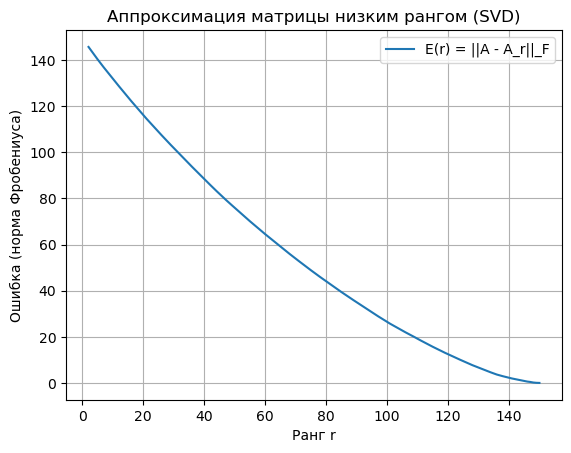

In [25]:
plt.figure()
plt.plot(ranks, errors, label='E(r) = ||A - A_r||_F')
plt.xlabel('Ранг r')
plt.ylabel('Ошибка (норма Фробениуса)')
plt.title('Аппроксимация матрицы низким рангом (SVD)')
plt.legend()
plt.grid(True)